# Lab 5: Function Approximation with Value Methods 

## Lab Assignment

Solve Gymnasium’s MountainCar-v0 using semi-gradient SARSA with tile coding. The observation space is Box([-1.2, -0.07], [0.6, 0.07]), representing position and velocity. Implement a tile coding feature constructor from scratch using NumPy with configurable number of tilings, tiles per dimension, and offset patterns. Start with 8 tilings of 8×8 tiles and experiment with variations.

Your tile coding implementation should: (1) discretize the continuous observation space into overlapping grids, (2) for each tiling, compute which tile the state falls into, (3) return a sparse binary feature vector (or use a list of active tile indices for efficiency). For each action, maintain a separate weight vector as a NumPy array.

Your RL implementation should: (1) extract the continuous observation from env.step(), (2) convert it to a feature vector using tile coding, (3) compute Q(s,a) as a linear function: Q = np.dot(weights[a], features), (4) perform semi-gradient updates after each step: weights[a] += alpha * (target - Q) * features. Implement ε-greedy action selection by computing Q-values for all actions.

Track episodes-to-goal over learning. Create visualizations of: (1) the learned value function as a heatmap over the 2D state space (position × velocity) by evaluating max_a Q(s,a) on a grid using NumPy’s meshgrid, (2) convergence curves for different feature configurations, (3) the learned policy shown as action choices across the state space, (4) sample trajectories from various starting positions overlaid on the value function.

Document how feature design choices (number of tilings, tile sizes, offsets) affect learning speed, final performance, and computational cost. Explain why MountainCar is difficult for tabular methods (hint: continuous state space would require infinite states) and how function approximation enables solving it.

In [1]:
import sys
sys.path.insert(0, '..')

from src.environment import MountainCarEnvironment

# DONE: Environment Setup
# - Verify the environment loads and runs correctly
# - Understand the observation and action spaces before building anything

env = MountainCarEnvironment()

print("Observation space:", env.observation_space)
print("  Low: ", env.observation_space.low)
print("  High:", env.observation_space.high)
print()
print("Action space:", env.action_space)
print("  n actions:", env.action_space.n)
print()

obs, info = env.reset()
print("Initial observation:", obs)

obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print("After one step:")
print("  obs:", obs)
print("  reward:", reward)
print("  terminated:", terminated, " truncated:", truncated)

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Low:  [-1.2  -0.07]
  High: [0.6  0.07]

Action space: Discrete(3)
  n actions: 3

Initial observation: [-0.4452088  0.       ]
After one step:
  obs: [-0.44679132 -0.00158252]
  reward: -1.0
  terminated: False  truncated: False


In [2]:
from src.tile_coder import TileCoder

# DONE: Tile Coding Feature Constructor
# - Build a tile coding component that maps a continuous observation to a feature representation
# - Support configurable number of tilings, tiles per dimension, and offset patterns
# - Verify correctness: the same state should always produce the same features

tc = TileCoder()

print("n_tilings:    ", tc.n_tilings)
print("tiles_per_dim:", tc.tiles_per_dim)
print("state_bounds: ", tc.state_bounds)
print("n_dims:       ", tc.n_dims)
print("tile_widths:  ", tc.tile_widths)
print("num_features: ", tc.num_features)
print()

# Verify: one active index per tiling
mid_state = [-0.5, 0.0]
tiles = tc.get_tiles(mid_state)
print(f"Active tiles for state {mid_state}: {tiles}")
print(f"Count: {len(tiles)} (expected {tc.n_tilings})")
print()

# Verify: all indices within valid range
assert all(0 <= i < tc.num_features for i in tiles), "Index out of range!"
print("All indices within [0, num_features): OK")
print()

# Verify: deterministic
assert tc.get_tiles(mid_state) == tc.get_tiles(mid_state), "Not deterministic!"
print("Determinism: OK")
print()

# Verify: different states produce different tiles
other_state = [0.0, 0.03]
assert tc.get_tiles(mid_state) != tc.get_tiles(other_state), "Different states should differ!"
print(f"Active tiles for state {other_state}: {tc.get_tiles(other_state)}")
print("Different states produce different tiles: OK")
print()

# Verify: boundary states don't crash
for label, state in [("lower bound", [-1.2, -0.07]), ("upper bound", [0.6, 0.07])]:
    t = tc.get_tiles(state)
    assert len(t) == tc.n_tilings
    print(f"{label} {state}: {t}")

n_tilings:     8
tiles_per_dim: [8, 8]
state_bounds:  [(-1.2, 0.6), (-0.07, 0.07)]
n_dims:        2
tile_widths:   [0.225  0.0175]
num_features:  512

Active tiles for state [-0.5, 0.0]: [28, 92, 156, 220, 284, 348, 412, 476]
Count: 8 (expected 8)

All indices within [0, num_features): OK

Determinism: OK

Active tiles for state [0.0, 0.03]: [45, 109, 173, 238, 302, 366, 438, 502]
Different states produce different tiles: OK

lower bound [-1.2, -0.07]: [0, 64, 128, 192, 256, 320, 384, 448]
upper bound [0.6, 0.07]: [63, 127, 191, 255, 319, 383, 447, 511]


In [3]:
import numpy as np
from src.sarsa_agent import SarsaAgent

# DONE: Semi-Gradient SARSA Agent
# - Implement action-value estimation as a linear function over tile-coded features
# - Implement epsilon-greedy action selection
# - Implement the semi-gradient SARSA weight update rule

agent = SarsaAgent(tc, n_actions=3)

print("Weights shape:", agent.weights.shape)
print("Weights initialized to zero:", np.all(agent.weights == 0.0))
print(f"alpha_eff: {agent.alpha_eff} (alpha={agent.alpha} / n_tilings={tc.n_tilings})")
print()

# Verify Q-value with zero weights
state = [-0.5, 0.0]
print(f"Q-values at {state} (zero weights): {[agent.q_value(state, a) for a in range(3)]}")
print()

# Verify action selection
print("Greedy action (zero weights):", agent.greedy_action(state))
print("Epsilon-greedy action:        ", agent.select_action(state))
print()

# Verify update changes weights for the selected action only
next_state = [-0.4, 0.01]
agent.update(state, 0, -1.0, next_state, 1, False)
print(f"Q-values after one update: {[agent.q_value(state, a) for a in range(3)]}")
print("Action 0 weights changed:  ", not np.all(agent.weights[0] == 0.0))
print("Action 1 weights unchanged:", np.all(agent.weights[1] == 0.0))
print("Action 2 weights unchanged:", np.all(agent.weights[2] == 0.0))
print()

# Verify reset
agent.reset_weights()
print("After reset, all weights zero:", np.all(agent.weights == 0.0))

Weights shape: (3, 512)
Weights initialized to zero: True
alpha_eff: 0.0125 (alpha=0.1 / n_tilings=8)

Q-values at [-0.5, 0.0] (zero weights): [0.0, 0.0, 0.0]

Greedy action (zero weights): 0
Epsilon-greedy action:         0

Q-values after one update: [-0.1, 0.0, 0.0]
Action 0 weights changed:   True
Action 1 weights unchanged: True
Action 2 weights unchanged: True

After reset, all weights zero: True


In [4]:
# DONE: Episode Recorder
# - During training, record (episode, step, position, velocity) to a CSV file
# - One row per step, written at episode end

In [5]:
from src.trainer import Trainer
from src.episode_recorder import EpisodeRecorder

# DONE: Training
# - Train the agent on MountainCar-v0 using a baseline configuration
# - Track episode length over time as the primary performance signal
# - Confirm the agent is learning (episode lengths should decrease)

tc = TileCoder()
agent = SarsaAgent(tc, n_actions=3)

with EpisodeRecorder("../results/trajectories.csv", reset=True) as recorder:
    trainer = Trainer(env, agent, n_episodes=500, seed=42, recorder=recorder)
    episode_lengths = trainer.train()

print(f"Episodes trained:       {len(episode_lengths)}")
print(f"First 10 episodes:      {episode_lengths[:10]}")
print(f"Last 10 episodes:       {episode_lengths[-10:]}")
print(f"Mean (first 100):       {np.mean(episode_lengths[:100]):.1f}")
print(f"Mean (last 100):        {np.mean(episode_lengths[-100:]):.1f}")
print(f"Best episode:           {min(episode_lengths)} steps")

Episodes trained:       500
First 10 episodes:      [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]
Last 10 episodes:       [169, 168, 164, 164, 163, 161, 182, 160, 165, 161]
Mean (first 100):       199.5
Mean (last 100):        165.5
Best episode:           148 steps


In [6]:
# DONE: Train the agent until convergence
# - Train in batches, monitoring the rolling mean episode length
# - Stop when the mean plateaus (improvement < threshold between batches)

BATCH_SIZE = 500
PLATEAU_THRESHOLD = 1.0
all_lengths = list(episode_lengths)  # carry forward from baseline training
prev_mean = np.mean(all_lengths[-BATCH_SIZE:])

print(f"Continuing from episode {len(all_lengths)}, rolling mean: {prev_mean:.1f}")
print()

batch = 1
with EpisodeRecorder("../results/trajectories.csv") as recorder:
    while True:
        trainer = Trainer(env, agent, n_episodes=BATCH_SIZE, recorder=recorder, seed=42, start_episode=len(all_lengths))
        batch_lengths = trainer.train()
        all_lengths.extend(batch_lengths)
        current_mean = np.mean(batch_lengths)
        improvement = prev_mean - current_mean
        print(f"Batch {batch:3d} | episodes {len(all_lengths):>6} | mean: {current_mean:.1f} | improvement: {improvement:.1f}")
        if improvement < PLATEAU_THRESHOLD:
            print()
            print("Plateau reached. Stopping.")
            break
        prev_mean = current_mean
        batch += 1

episode_lengths = all_lengths
print()
print(f"Total episodes:         {len(episode_lengths)}")
print(f"Final mean (last {BATCH_SIZE}): {np.mean(episode_lengths[-BATCH_SIZE:]):.1f}")
print(f"Best episode:           {min(episode_lengths)} steps")

Continuing from episode 500, rolling mean: 176.8

Batch   1 | episodes   1000 | mean: 155.1 | improvement: 21.8
Batch   2 | episodes   1500 | mean: 156.7 | improvement: -1.6

Plateau reached. Stopping.

Total episodes:         1500
Final mean (last 500): 156.7
Best episode:           93 steps


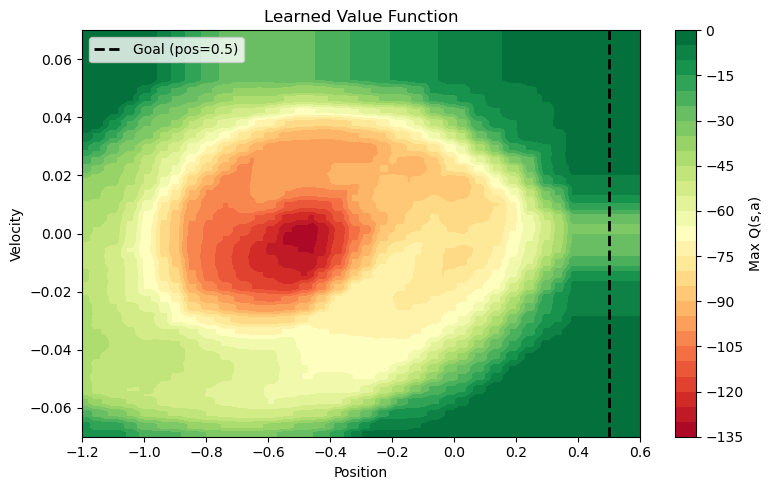

In [7]:
from src.visualizer import Visualizer

# DONE: Visualization: Value Function
# - Show the learned value function as a heatmap over the 2D state space (position x velocity)

viz = Visualizer(agent)
_ = viz.plot_value_function()

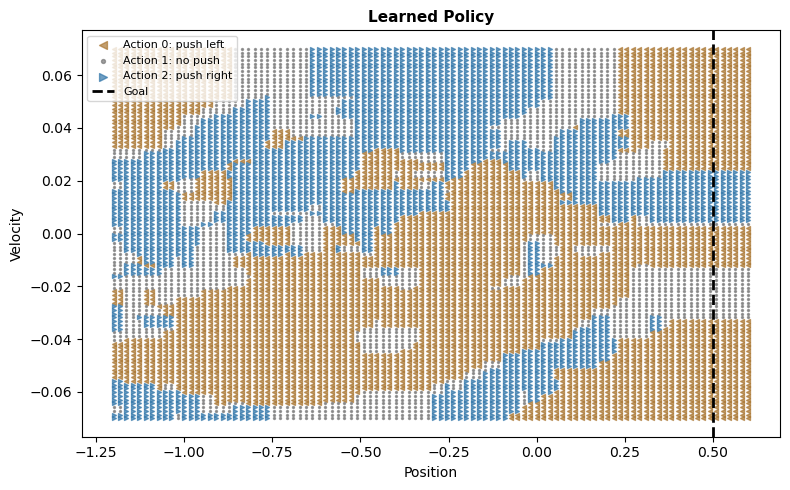

In [8]:
# DONE: Visualization: Learned Policy
# - Show the greedy action chosen by the agent across the 2D state space
_ = viz.plot_policy()

 Start pos   Steps  Outcome
------------------------------
     -1.20      43  success
     -0.80     115  success
     -0.40     100  success
      0.00      78  success
      0.40      84  success


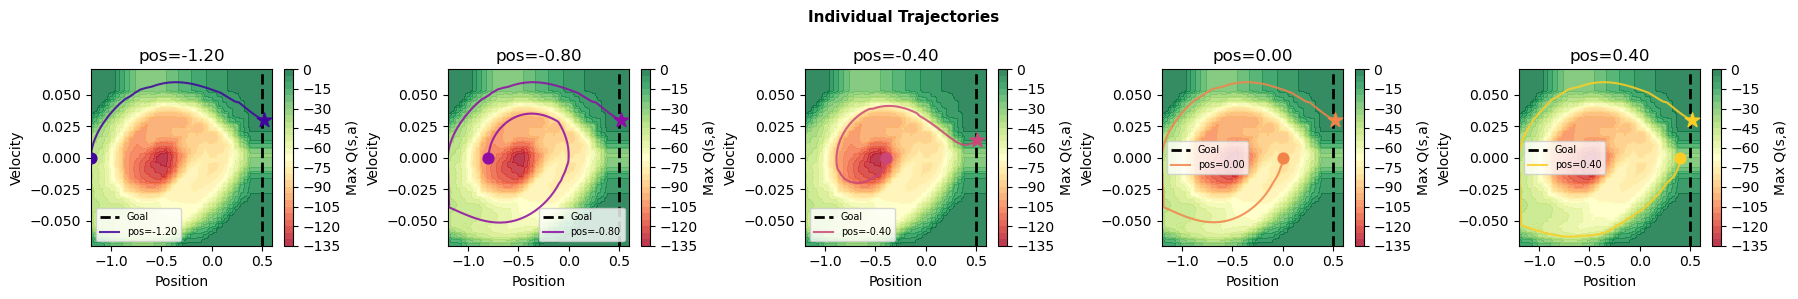

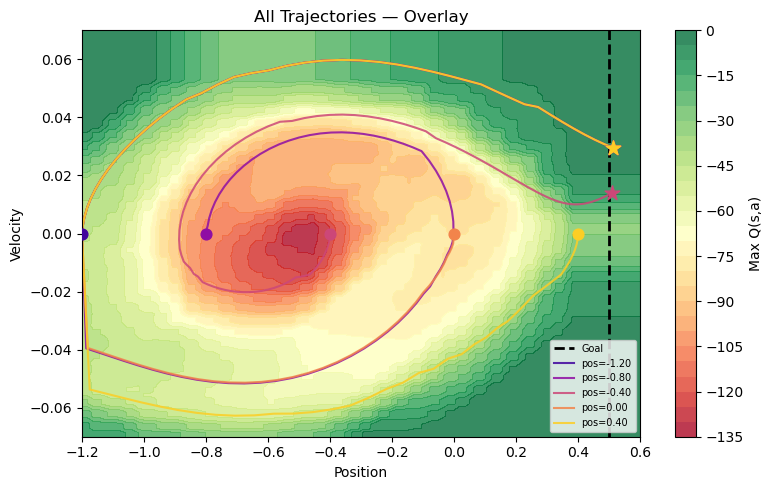

In [9]:
# DONE: Visualization: Sample Trajectories
# - Run greedy rollouts from several starting positions using the trained agent
# - Thumbnail per trajectory, then a combined overlay on the value function heatmap

import numpy as np
import matplotlib.pyplot as plt

START_POSITIONS = np.linspace(-1.2, 0.4, 5).tolist()  # evenly spaced across the valid range; velocity=0 for all
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(START_POSITIONS)))

trajectories, labels, rows = [], [], []
for pos in START_POSITIONS:
    env.reset(seed=0)
    env._env.unwrapped.state = [pos, 0.0]
    state = list(env._env.unwrapped.state)

    traj = [state[:]]
    done = False
    while not done:
        action = agent.greedy_action(state)
        next_state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = list(next_state)
        traj.append(state[:])

    trajectories.append(traj)
    reached_goal = state[0] >= 0.5
    outcome = 'success' if reached_goal else 'truncated'
    labels.append(f'pos={pos:.2f}')
    rows.append((pos, len(traj), outcome))

print(f"{'Start pos':>10}  {'Steps':>6}  {'Outcome'}")
print("-" * 30)
for pos, steps, outcome in rows:
    print(f"{pos:>10.2f}  {steps:>6}  {outcome}")

# Thumbnails — each uses its own color from the shared palette
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, (ax, traj, label) in enumerate(zip(axes, trajectories, labels)):
    viz.plot_trajectories([traj], labels=[label], colors=[colors[i]], ax=ax, title=label)
fig.suptitle('Individual Trajectories', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Overlay — same palette
_ = viz.plot_trajectories(trajectories, labels=labels, colors=colors, title='All Trajectories — Overlay')

Animating episode 1250  (181 steps)


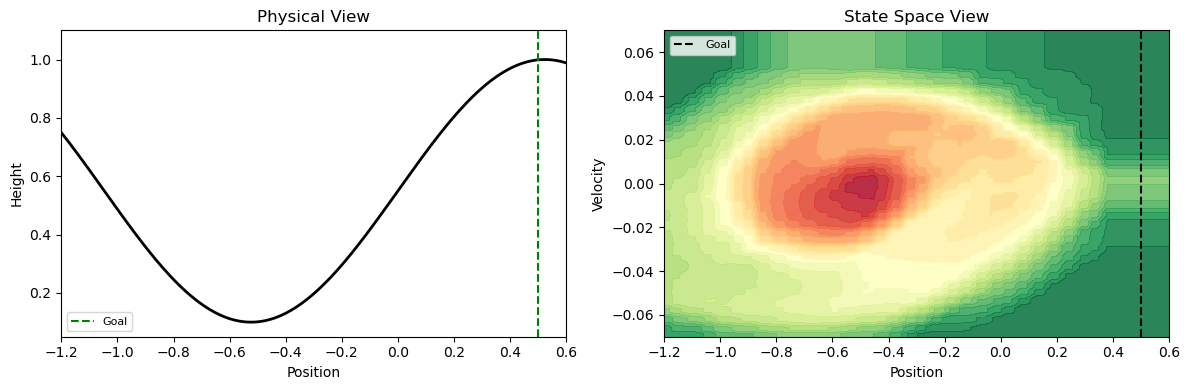

In [ ]:
import pandas as pd
from matplotlib import rc
rc('animation', html='jshtml')

# DONE: Episode Player
# - Read a recorded CSV and animate the trajectory using two synchronized panels:
#   (1) physical view: the car moving along the hill profile in 1D
#   (2) state space view: a scatter point tracing the trajectory on the value function heatmap (position x velocity)
# - Use matplotlib animation

df = pd.read_csv('../results/trajectories.csv')

# Pick a representative successful episode from the final third of training
final_third_start = df['episode'].max() * 2 // 3
final_episodes = df[df['episode'] >= final_third_start]['episode'].unique()
episode_id = int(final_episodes[len(final_episodes) // 2])

traj_df = df[df['episode'] == episode_id]
trajectory = traj_df[['position', 'velocity']].values.tolist()

print(f"Animating episode {episode_id}  ({len(trajectory)} steps)")

anim = viz.animate_episode(trajectory);
anim

In [11]:
# TODO: Agent Persistence
# - Save a trained agent's weight vectors to disk so training does not need to be repeated
# - Load a saved agent to support visualization and episode playback without retraining

In [12]:
# TODO: Feature Design Experiments
# - Maintain an experiment registry that maps short labels (Ex1, Ex2, ...) to their full configurations
# - Each experiment run records its label, aggregate metrics, and a reference to its per-step trajectory file
# - Compare the effect of varying number of tilings and tile resolution on learning speed, final performance, and computational cost
# - Results feed directly into the convergence curves visualization and the analysis

In [13]:
# TODO: Visualization: Convergence Curves
# - Show how episode length evolves over training
# - Required: curves for multiple feature configurations on the same plot (not just the baseline)

In [14]:
# TODO: Analysis
# - Explain why MountainCar is difficult for tabular methods
# - Explain how tile coding addresses this and what trade-offs it introduces
# - Connect the experimental results to the theory